# Geospatial Machine Learning — Part 2: Exploratory Spatial Data Analysis (ESDA)

The EDA (Part 1) looked at the values of sand content. This notebook looks at **where** those values occur: are similar sand contents found close to each other?

This matters for modeling because:

- if nearby samples are similar (**spatial autocorrelation**), a random train/test split puts near-duplicate samples on both sides and the validation becomes overly optimistic (this motivates the spatial cross-validation in Part 4);
- the distance over which samples remain similar (**range**) helps choose the size of neighborhood-based predictors, such as the 11 × 11 pixel window used in `TPI_11x11`.

Two complementary tools are used:

1. **Global Moran's I**: tests whether similar values tend to occur at neighboring locations, with neighbors defined by a spatial weights matrix.
2. **Semivariogram**: describes how the dissimilarity between pairs of samples grows with the distance between them, and estimates the range of spatial dependence.

The data are the same sand samples (0–50 cm) in a projected CRS (EPSG:5880, meters), so that distances are measured in meters. The workflow is intentionally organized step by step for teaching purposes.

In [1]:
# ============================================================
# 0. Install the required packages
# ============================================================

# Run this cell only if the packages are not already available
# in the current Python environment.

%pip install geopandas libpysal esda scikit-gstat matplotlib scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# 1. Import the required libraries
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from libpysal.weights import KNN
from libpysal.weights.spatial_lag import lag_spatial
from esda.moran import Moran
from skgstat import Variogram

In [3]:
# ============================================================
# 2. Read and prepare the spatial dataset
# ============================================================

# Path to the GeoPackage containing the soil sampling points
INPUT_DIR = Path("input")
file_path = INPUT_DIR / "c3_soildata_psd_modeling_meters_0_50cm.gpkg"

# Read the point dataset as a GeoDataFrame
gdf = gpd.read_file(file_path)

# Display basic information about the dataset
print("Number of observations:", len(gdf))
print("CRS:", gdf.crs)
print(gdf.head())

# Drop layers made only of coarse fragments (esqueleto = 1000 g/kg).
# They contain no fine earth, so sand = 0 there is not a measurement.
gdf = gdf[gdf["esqueleto"] < 1000].copy()

# Convert sand content from the original 0-1000 scale to percentage
gdf["sand_pct"] = gdf["areia"] / 10.0

# Remove observations with missing values in the response variable
gdf = gdf.dropna(subset=["sand_pct"]).copy()

# Reset the index so the spatial weights matrix and attribute values
# remain aligned throughout the analysis
gdf = gdf.reset_index(drop=True)

# Check whether the CRS uses geographic coordinates (degrees).
# Distance-based analyses such as the semivariogram should preferably
# use a projected CRS with linear units, such as meters.
if gdf.crs is None:
    raise ValueError("The dataset has no CRS defined.")

if gdf.crs.is_geographic:
    raise ValueError(
        "The dataset is in a geographic CRS. Reproject it to an appropriate "
        "projected CRS before calculating distance-based statistics."
    )

print("\nPrepared observations:", len(gdf))
print(gdf["sand_pct"].describe())

Number of observations: 14829
CRS: EPSG:5880
                              id  longitude   latitude  profundidade  \
0  clay-copy-ctb0004-RosĂˇrio-26 -35.134160  -8.576835          40.0   
1           clay-copy-ctb0019-P1 -50.231766 -29.475679          44.0   
2       clay-copy-ctb0033-RO1271 -64.059444 -11.770000          50.0   
3       clay-copy-ctb0033-RO1279 -64.330278 -12.018333          45.0   
4       clay-copy-ctb0033-RO1303 -63.941667  -9.891667          45.0   

   esqueleto  areia  silte  argila  log_silte1p_argila1p  \
0          0    200    150     650             -1.461230   
1          0    120    250     630             -0.921853   
2          0    157     67     776             -2.435933   
3          0     60    200     740             -1.304696   
4        400    260     70     670             -2.237736   

   log_areia1p_argila1p  log_esqueleto1p_argila1p  \
0             -1.175205                 -6.478510   
1             -1.651515                 -6.447306   
2 

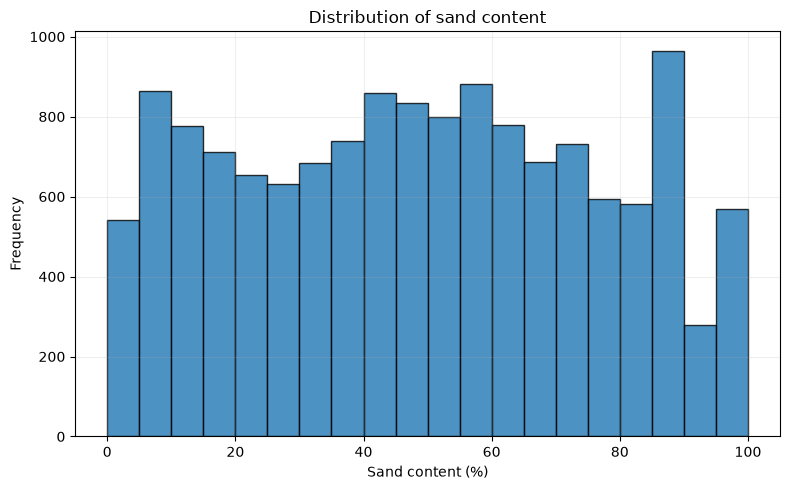

In [4]:
# ============================================================
# 3. Explore the response variable before spatial analysis
# ============================================================

# A basic exploratory analysis is useful before calculating spatial
# statistics. Here we inspect the distribution of sand content.

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    gdf["sand_pct"],
    bins=20,
    edgecolor="black",
    alpha=0.8
)

ax.set_xlabel("Sand content (%)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of sand content")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Global Moran's I

Moran's I compares the value at each location with the average value of its **neighbors**. Here the neighbors of a sample are its *k* = 8 nearest samples (a *k*-nearest-neighbors weights matrix).

- **I > 0**: neighbors have similar values (clustering of high values near high values, low near low);
- **I ≈ 0**: no spatial pattern (spatial randomness);
- **I < 0**: neighbors tend to have opposite values (a checkerboard pattern).

Significance is assessed with a permutation test: the values are randomly shuffled among the locations 999 times, and the observed I is compared with the I values obtained under randomness.

In [5]:
# ============================================================
# 4. Calculate Global Moran's I for one neighborhood definition
# ============================================================

# Define the number of nearest neighbors.
# Here, each sampling location is connected to its 8 nearest neighbors.
k = 8

# Build the k-nearest-neighbors spatial weights matrix
w = KNN.from_dataframe(gdf, k=k)

# Row-standardize the weights.
# After this transformation, the weights associated with each observation
# sum to 1, which makes the spatial lag easier to interpret.
w.transform = "R"

# Set a random seed so the permutation test is reproducible
np.random.seed(42)

# Calculate Global Moran's I using 999 random permutations
moran = Moran(
    gdf["sand_pct"].values,
    w,
    permutations=999
)

# Display the main results
print(f"Number of neighbors (k): {k}")
print(f"Connected components: {w.n_components}")
print(f"Moran's I: {moran.I:.4f}")
print(f"Expected I: {moran.EI:.6f}")
print(f"Permutation p-value: {moran.p_sim:.4f}")
print(f"Permutation z-score: {moran.z_sim:.3f}")

/opt/conda/envs/geospatial/lib/python3.13/site-packages/libpysal/weights/distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 33 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Number of neighbors (k): 8
Connected components: 33
Moran's I: 0.6232
Expected I: -0.000071
Permutation p-value: 0.0010
Permutation z-score: 149.811


The Global Moran's I value (**I = 0.623**) indicates a strong positive spatial autocorrelation in sand content. In other words, sampling locations with similar sand percentages tend to occur near one another more often than expected under spatial randomness.

The permutation test confirms that this spatial pattern is statistically significant (**p = 0.001**, the smallest value possible with 999 permutations). The expected Moran's I under the null hypothesis is approximately zero (**E[I] = −0.00007**), reinforcing the contrast between the observed pattern and spatial randomness.

However, the k-nearest-neighbor spatial weights matrix contains **33 disconnected components**, indicating that the sampling network is not fully connected when using **k = 8**: some clusters of samples are only linked among themselves. Therefore, the magnitude of Moran's I should be interpreted in relation to this specific neighborhood definition, and its sensitivity to alternative values of *k* is examined below.

## Moran scatterplot

Each point is a sample: the horizontal axis is its standardized sand content and the vertical axis is the average standardized sand content of its neighbors (the *spatial lag*). The slope of the fitted line equals Moran's I. The four quadrants separate:

- **High-High** (top right) and **Low-Low** (bottom left): samples similar to their neighbors, which drive positive autocorrelation;
- **High-Low** and **Low-High**: samples that differ from their neighbors (spatial outliers).

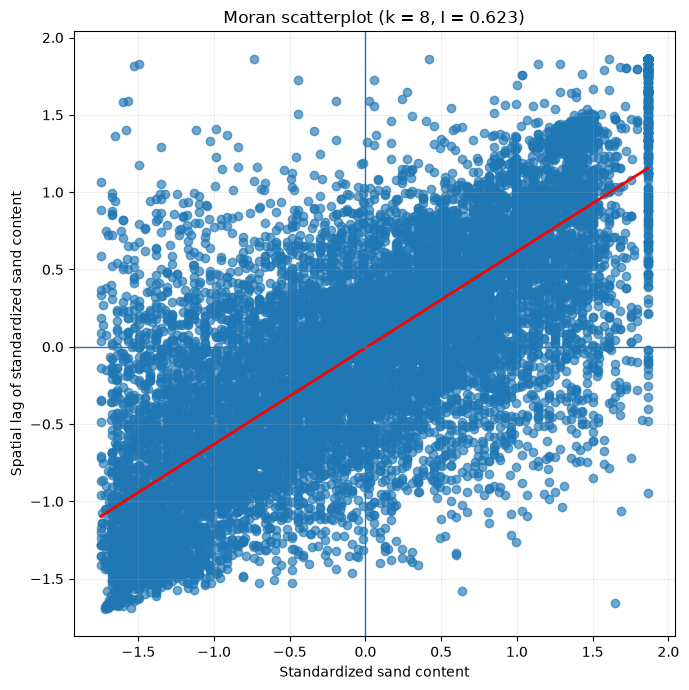

In [6]:
# ============================================================
# 5. Create a Moran scatterplot
# ============================================================

# Standardize sand content to mean 0 and standard deviation 1.
# The horizontal axis of the Moran scatterplot represents the standardized
# value at each location.
y = gdf["sand_pct"].to_numpy()
z = (y - y.mean()) / y.std(ddof=0)

# Calculate the spatial lag of the standardized variable.
# This represents the weighted average of neighboring standardized values.
wz = lag_spatial(w, z)

# Fit a simple straight line for visualization.
# With row-standardized weights and standardized values, its slope is
# closely related to Global Moran's I.
slope, intercept = np.polyfit(z, wz, 1)
x_line = np.linspace(z.min(), z.max(), 200)

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(z, wz, alpha=0.65)
ax.plot(x_line, intercept + slope * x_line, linewidth=2, color='red')

# Reference lines divide the plot into the four conventional quadrants:
# High-High, Low-Low, High-Low, and Low-High.
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlabel("Standardized sand content")
ax.set_ylabel("Spatial lag of standardized sand content")
ax.set_title(f"Moran scatterplot (k = {k}, I = {moran.I:.3f})")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Sensitivity to the neighborhood definition

The value of Moran's I depends on how neighbors are defined. To check whether the conclusion holds, we repeat the test for several values of *k*, from very local neighborhoods (*k* = 4) to broader ones (*k* = 50). The number of **connected components** shows whether the neighborhood graph links all samples into one network (1 component) or leaves isolated groups of samples.

In [7]:
# ============================================================
# 6. Sensitivity analysis: Moran's I across different k values
# ============================================================

# Moran's I depends on how spatial neighbors are defined.
# We therefore repeat the analysis for several values of k.
k_values = [4, 6, 8, 10, 12, 16, 20, 30, 40, 50]

results = []

for k_test in k_values:

    # Build a new k-nearest-neighbors weights matrix
    w_test = KNN.from_dataframe(gdf, k=k_test)
    w_test.transform = "R"

    # Use the same random seed before each permutation test so that
    # the exercise is reproducible across notebook executions.
    np.random.seed(42)

    moran_test = Moran(
        gdf["sand_pct"].values,
        w_test,
        permutations=999
    )

    # Store the statistics needed for comparison
    results.append({
        "k": k_test,
        "Moran_I": moran_test.I,
        "Expected_I": moran_test.EI,
        "p_value": moran_test.p_sim,
        "z_score": moran_test.z_sim,
        "components": w_test.n_components
    })

# Convert the list of dictionaries to a DataFrame
moran_results = pd.DataFrame(results)

# Display the complete sensitivity table
moran_results

/opt/conda/envs/geospatial/lib/python3.13/site-packages/libpysal/weights/distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 106 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/opt/conda/envs/geospatial/lib/python3.13/site-packages/libpysal/weights/distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 56 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/opt/conda/envs/geospatial/lib/python3.13/site-packages/libpysal/weights/distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 33 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/opt/conda/envs/geospatial/lib/python3.13/site-packages/libpysal/weights/distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 25 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/opt/conda/envs/geospatial/lib/python3.

,k,Moran_I,Expected_I,p_value,z_score,components
0,4,0.656384,-0.000071,0.001,116.276746,106
1,6,0.639119,-0.000071,0.001,134.470547,56
2,8,0.623175,-0.000071,0.001,149.811187,33
3,10,0.610145,-0.000071,0.001,165.470395,25
4,12,0.601561,-0.000071,0.001,183.004403,19
5,16,0.586059,-0.000071,0.001,203.725343,3
6,20,0.571814,-0.000071,0.001,221.574599,2
7,30,0.548228,-0.000071,0.001,267.027724,2
8,40,0.531502,-0.000071,0.001,298.925675,2
9,50,0.517247,-0.000071,0.001,320.361621,1


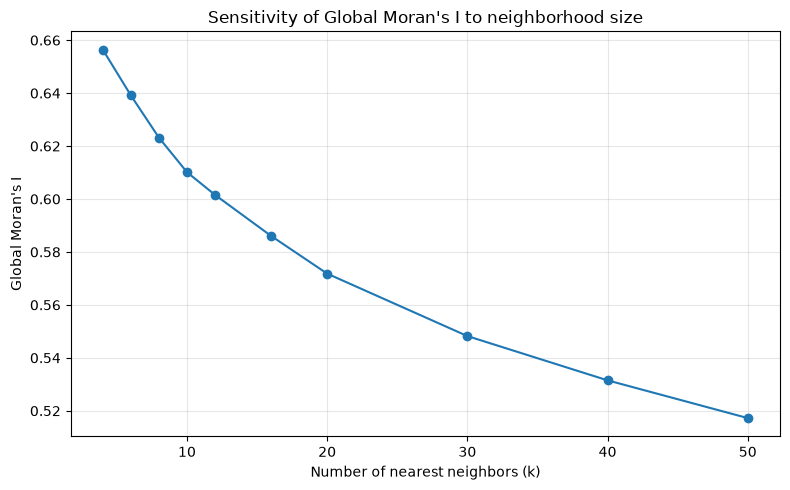

In [8]:
# ============================================================
# 7. Plot Moran's I as a function of neighborhood size
# ============================================================

# This plot helps reveal whether the estimated degree of spatial
# autocorrelation changes as progressively more distant neighbors
# are included in the spatial weights matrix.

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    moran_results["k"],
    moran_results["Moran_I"],
    marker="o"
)

ax.set_xlabel("Number of nearest neighbors (k)")
ax.set_ylabel("Global Moran's I")
ax.set_title("Sensitivity of Global Moran's I to neighborhood size")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Moran's I is positive and statistically significant for all tested values of *k* (permutation *p* = 0.001), indicating a consistent pattern of positive spatial autocorrelation in sand content.

As *k* increases, Moran's I decreases gradually from **0.66 for *k* = 4** to **0.52 for *k* = 50**. Spatial dependence is therefore strongest between the closest samples and weakens as increasingly distant neighbors are included in the spatial weights matrix. This is typical of soil properties, which change progressively with distance.

The number of disconnected components also drops quickly as *k* increases: from **106 components for *k* = 4** to 3 for *k* = 16 and 2 for *k* = 20–40. The graph only becomes fully connected at ***k* = 50**. Small values of *k* thus produce higher Moran's I values, but describe a more fragmented neighborhood structure.

Overall, the conclusion of positive spatial autocorrelation is robust to the choice of *k*. However, both the magnitude of Moran's I and the topology of the spatial weights matrix depend on the neighborhood definition, which reinforces the importance of evaluating several neighborhood sizes rather than selecting a single value of *k* arbitrarily.

## Semivariogram and spatial range

Moran's I and the semivariogram describe spatial structure from different perspectives. Moran's I requires an explicit definition of neighborhood, whereas the semivariogram summarizes how pairwise dissimilarity changes with distance.

For observations separated by distance $h$, the empirical semivariance is

$$
\gamma(h) = \frac{1}{2N(h)} \sum_{(i,j) \in N(h)} \left[z(s_i) - z(s_j)\right]^2
$$

where $N(h)$ is the set of observation pairs belonging to a distance class around $h$.

A fitted semivariogram model is described by three parameters:

- **nugget**: the semivariance at distance zero (measurement error and variation at scales shorter than the sampling spacing);
- **sill**: the plateau that the semivariance reaches when samples are no longer related;
- **range**: the distance at which the sill is (effectively) reached. Beyond this distance, spatial dependence is substantially reduced according to the fitted model.

**Why remove a trend first?** Sand content also varies at the scale of the whole country (a broad north–south / east–west gradient). This large-scale trend inflates the semivariance at all distances and hides the local structure. We therefore fit a linear trend on the x and y coordinates and compute the semivariogram of the **residuals**.

In [9]:
# ============================================================
# 8. Prepare coordinates and values for the semivariogram
# ============================================================

# Extract x and y coordinates from the point geometries.
# Because the CRS was checked above, these coordinates are assumed to use
# projected linear units, preferably meters.
coordinates = np.column_stack([
    gdf.geometry.x.to_numpy(),
    gdf.geometry.y.to_numpy()
])

# Extract the response variable as a NumPy array
values = gdf["sand_pct"].to_numpy()

print("Coordinate units are defined by the dataset CRS:", gdf.crs)
print("Number of observations used in the variogram:", len(values))

Coordinate units are defined by the dataset CRS: EPSG:5880
Number of observations used in the variogram: 14165


In [10]:
# ============================================================
# 9. Remove a broad-scale spatial trend
# ============================================================

from sklearn.linear_model import LinearRegression

# Use projected x and y coordinates to represent a broad-scale
# spatial trend across the study area.
#
# This is a simple trend-surface approach used here for
# exploratory purposes.
X_trend = coordinates

# Fit a linear spatial trend.
trend_model = LinearRegression()
trend_model.fit(X_trend, values)

# Predict the broad-scale spatial trend.
trend = trend_model.predict(X_trend)

# Calculate residuals.
#
# Residuals represent the variation that remains after removing
# the broad-scale linear spatial trend.
residuals = values - trend

print(f"Mean residual: {residuals.mean():.4f}")
print(f"Residual standard deviation: {residuals.std():.4f}")

Mean residual: -0.0000
Residual standard deviation: 27.3610


In [11]:
# ============================================================
# 10. Fit a semivariogram to the residuals
# ============================================================

V_residual = Variogram(
    coordinates=coordinates,
    values=residuals,
    model="spherical",
    n_lags=20,
    maxlag=30_000,   # 30 km
    normalize=False,
    use_nugget=True
)

# Retrieve fitted variogram parameters.
description_residual = V_residual.describe()

range_residual = description_residual["effective_range"]
sill_residual = description_residual["sill"]
nugget_residual = description_residual["nugget"]

print("Residual variogram parameters:")
print(f"Range:  {range_residual / 1000:.1f} km")
print(f"Sill:   {sill_residual:.2f}")
print(f"Nugget: {nugget_residual:.2f}")

Residual variogram parameters:
Range:  6.3 km
Sill:   469.10
Nugget: 0.00


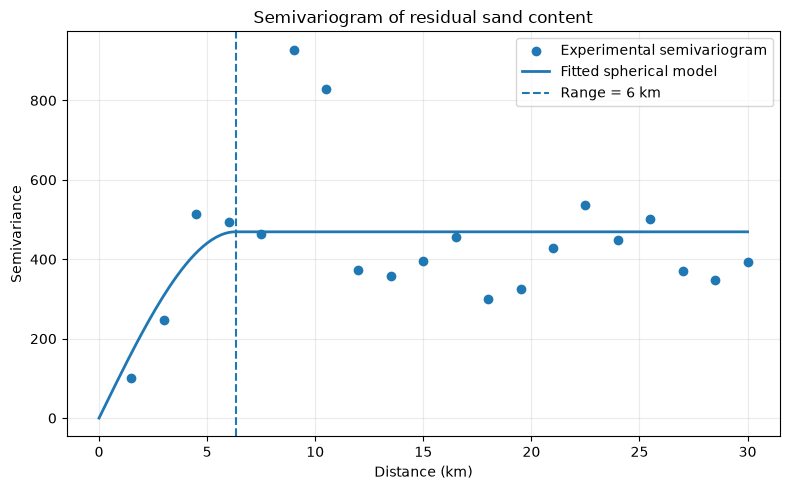

In [12]:
# ============================================================
# 11. Plot the empirical and fitted residual semivariogram
# ============================================================

# V_residual.bins contains the representative distance of each lag class.
# V_residual.experimental contains the empirical semivariance calculated
# from the residuals after removing the broad-scale spatial trend.
lag_distances = V_residual.bins
experimental_semivariance = V_residual.experimental

# Create a smooth sequence of distances for plotting the fitted
# spherical variogram model.
x_model = np.linspace(
    0,
    lag_distances.max(),
    300
)

# Evaluate the fitted variogram model at each distance.
fitted_semivariance = V_residual.fitted_model(x_model)

# ------------------------------------------------------------
# Create the figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

# Plot the empirical semivariogram.
#
# Each point represents the average semivariance for one
# distance class (lag).
ax.scatter(
    lag_distances / 1000,
    experimental_semivariance,
    label="Experimental semivariogram",
    zorder=3
)

# Plot the fitted spherical variogram model.
ax.plot(
    x_model / 1000,
    fitted_semivariance,
    linewidth=2,
    label="Fitted spherical model"
)

# Mark the estimated spatial range.
#
# The range represents the approximate distance over which
# spatial dependence remains in the residuals.
ax.axvline(
    range_residual / 1000,
    linestyle="--",
    linewidth=1.5,
    label=f"Range = {range_residual / 1000:.0f} km"
)

# ------------------------------------------------------------
# Figure formatting
# ------------------------------------------------------------

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Semivariance")

ax.set_title(
    "Semivariogram of residual sand content"
)

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 12. Optional: compare a few theoretical variogram models
# ============================================================

# Comparing alternative theoretical models for the detrended residuals is useful because the estimated
# range can change with model choice. Here we compare three common models
# using the root mean squared error (RMSE) reported by SciKit-GStat.
models = ["spherical", "exponential", "gaussian"]
model_results = []

for model_name in models:

    V_test = Variogram(
        coordinates=coordinates,
        values=residuals,
        model=model_name,
        n_lags=20,
        maxlag=30_000,   # 30 km
        normalize=False,
        use_nugget=True
    )

    description = V_test.describe()

    model_results.append({
        "model": model_name,
        "range": description["effective_range"],
        "sill": description["sill"],
        "nugget": description["nugget"],
        "RMSE": V_test.rmse
    })

variogram_models = pd.DataFrame(model_results)
variogram_models

,model,range,sill,nugget,RMSE
0,spherical,6315.867200,469.098285,4.460782e-19,153.744697
1,exponential,6559.784458,467.516005,4.100946e-06,159.014048
2,gaussian,5875.976685,470.468213,9.372005e-12,152.839281


The three variogram models fitted to the detrended residuals give a consistent scale of spatial dependence, with effective ranges between approximately **5.9 km (Gaussian) and 6.6 km (exponential)**; the spherical model gives 6.3 km. The Gaussian model has the lowest RMSE, but its improvement over the spherical model is small. The main conclusion is therefore robust to the choice of variogram function: **residual spatial dependence occurs mainly within about 6 km**.

The estimated nugget is practically zero for all models, while the sill is approximately 470 (%²). This indicates that most of the residual variability is spatially structured within the analyzed distances, rather than unresolved variability at distances shorter than the sampling spacing. Note that only pairs up to 30 km apart were used (`maxlag`), so this describes the short-range structure; the broad-scale variation was removed with the linear trend.

**Implication for feature engineering.** The range gives an empirical reference for the spatial extent over which neighboring environmental information may be relevant. With rasters of about 1 km resolution, a radius of ~6 km corresponds to about six pixels in each direction, i.e. a **13 × 13 pixel moving window**. The **11 × 11 window** used for `TPI_11x11` (radius of ~5 km) is slightly smaller than the estimated range but of the same order, and is therefore a reasonable choice. The variogram range should be treated as a guide for selecting candidate neighborhood sizes, not as an exact kernel size that must be used in the predictive model.

**Implication for validation.** Samples closer than ~6 km share information. A random train/test split (Part 3) places many test samples within this distance of training samples, which inflates the validation metrics. Spatial blocks much larger than the range (2° ≈ 220 km in Part 4) avoid this.